<a href="https://colab.research.google.com/github/jorgefbarreiros/codes/blob/main/madrid1953.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    period  risk_premium  q_expectations  investment  imported_capital_goods  \
0        0        -1.000           1.200       2.240                   2.128   
1        1        -0.720           1.584       3.485                   4.268   
2        2        -0.518           1.572       3.870                   5.597   
3        3        -0.373           1.391       3.710                   6.043   
4        4        -0.269           1.157       3.274                   5.830   
5        5        -0.193           0.927       2.741                   5.227   
6        6        -0.139           0.723       2.213                   4.455   
7        7        -0.100           0.554       1.742                   3.660   
8        8        -0.072           0.419       1.346                   2.926   
9        9        -0.052           0.314       1.025                   2.291   
10      10        -0.037           0.233       0.773                   1.765   
11      11        -0.027           0.172

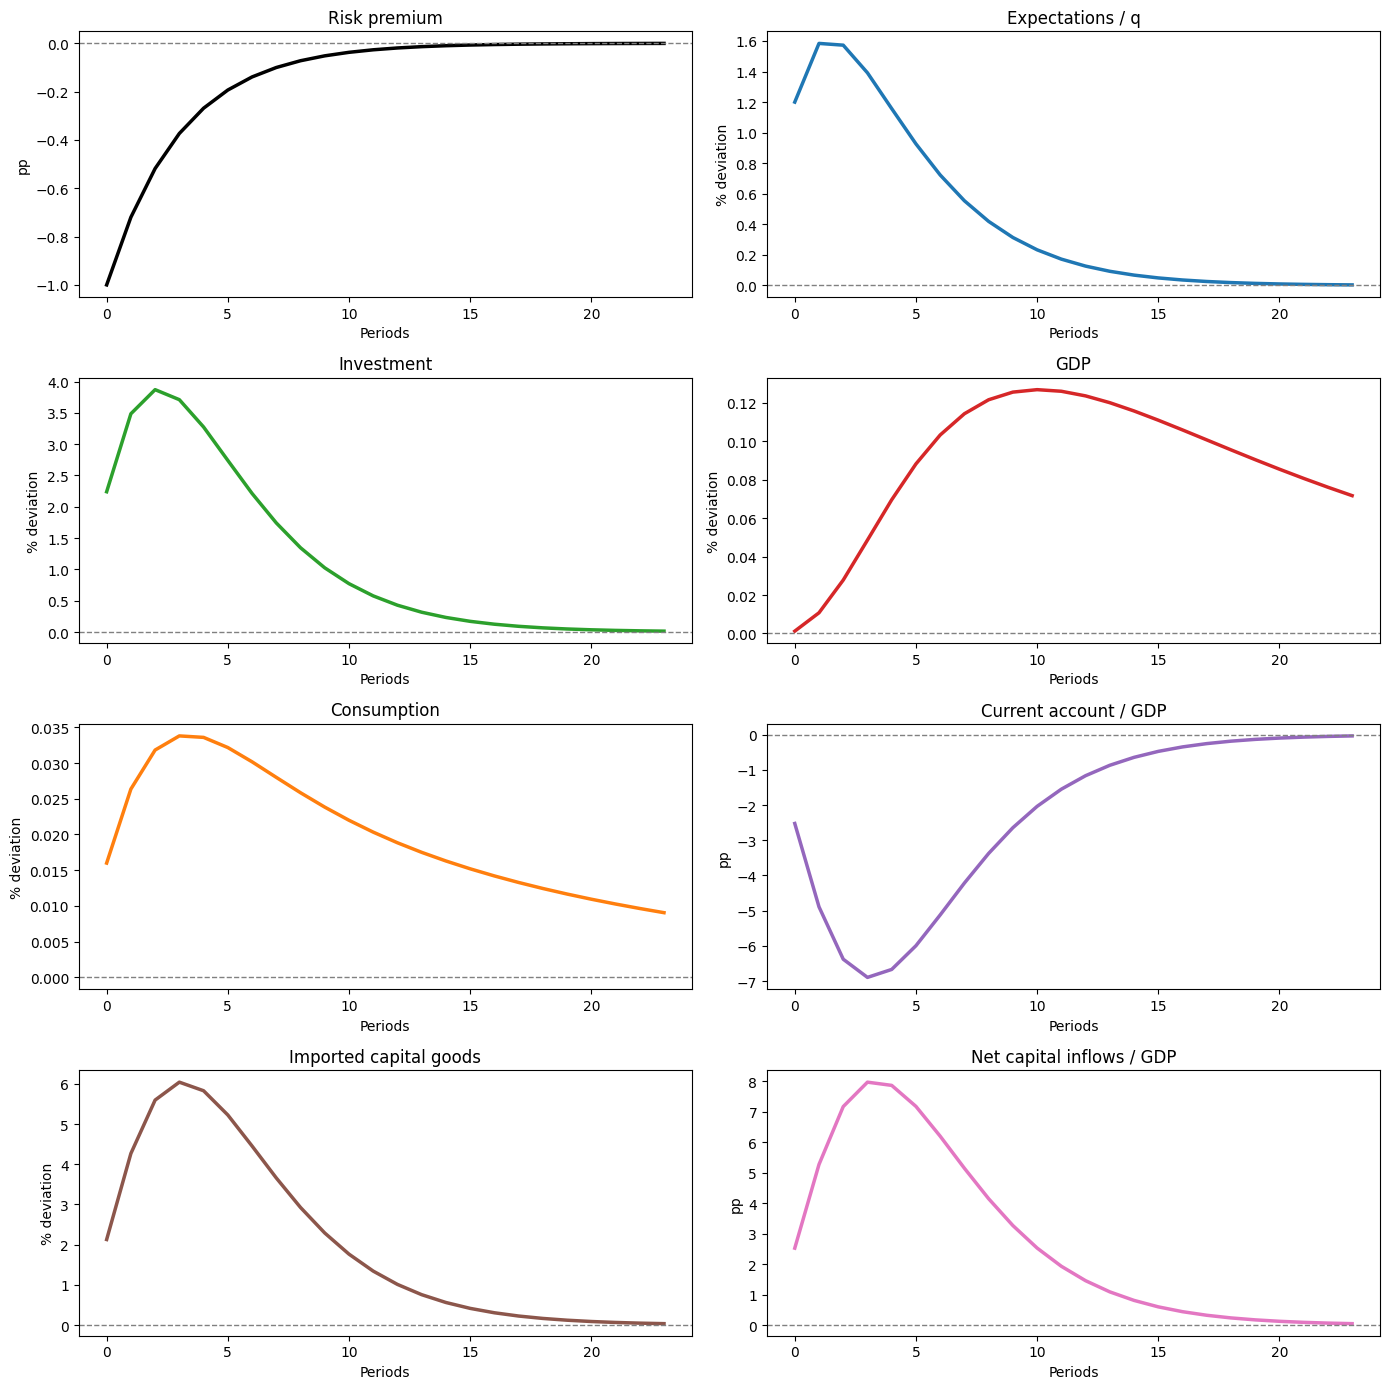


Saved: irf_financial_expectational_shock_spain_1953_recalibrated.csv

IRF summary:
                     impact  peak_positive  t_peak_positive  peak_negative  \
risk_premium         -1.000         -0.001             23.0         -1.000   
investment            2.240          3.870              2.0          0.014   
gdp                   0.001          0.127             10.0          0.001   
consumption           0.016          0.034              3.0          0.009   
ca_gdp               -2.524         -0.036             23.0         -6.895   
net_capital_inflows   2.524          7.971              3.0          0.046   

                     t_peak_negative  cumulative_8_periods  
risk_premium                     0.0                -3.313  
investment                      23.0                23.275  
gdp                              0.0                 0.464  
consumption                     23.0                 0.232  
ca_gdp                           3.0               -42.692  
net

In [7]:
# ============================================================
# SMALL OPEN ECONOMY WITH EXPECTATIONS AND INVESTMENT FRICTIONS
# Recalibrated version: strong investment response, weak GDP and consumption
# Historical interpretation: Spain after the 1953 Madrid Pacts
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. CALIBRATION
# ------------------------------------------------------------
# Conventions:
# - gdp, consumption, investment, q, capital, imports_k:
#     percent deviations from steady state
# - risk_premium, ca_gdp, net_capital_inflows:
#     percentage points
#
# Targeted qualitative pattern:
# - large fall in risk premium
# - strong increase in investment
# - clear deterioration in CA/GDP
# - very muted response of GDP
# - almost flat consumption

params = {
    "T": 24,

    # Financial-expectational shock
    "rp_shock_0": -1.0,
    "rho_rp": 0.72,

    # Expectations / q
    "rho_q": 0.60,
    "gamma_q_rp": 1.20,

    # Investment
    "rho_i": 0.45,
    "phi_i_q": 1.20,
    "phi_i_rp": 0.80,
    "phi_i_y": 0.01,

    # Imported capital goods
    "rho_mk": 0.45,
    "phi_mk_i": 0.95,

    # Capital accumulation with stronger time-to-build friction
    "delta_k": 0.06,
    "time_to_build_share": 0.10,

    # Consumption: very muted response
    "rho_c": 0.70,
    "phi_c_y": 0.03,
    "phi_c_rp": 0.01,
    "phi_c_q": 0.005,

    # GDP: much weaker contemporaneous and delayed response
    "rho_y": 0.15,
    "alpha_k": 0.06,
    "alpha_c": 0.04,
    "alpha_i_dom": 0.005,
    "alpha_rp_prod": 0.0,

    # Current account / GDP
    "rho_ca": 0.20,
    "psi_ca_y": 0.05,
    "psi_ca_i": 0.35,
    "psi_ca_mk": 0.70,
    "psi_ca_rp": 0.25,

    # Net capital inflows
    "rho_kf": 0.15
}

# ------------------------------------------------------------
# 2. SIMULATION FUNCTION
# ------------------------------------------------------------
def simulate_irf(p):
    T = p["T"]

    risk_premium = np.zeros(T)
    q = np.zeros(T)
    investment = np.zeros(T)
    imports_k = np.zeros(T)
    domestic_investment = np.zeros(T)
    capital = np.zeros(T)
    gdp = np.zeros(T)
    consumption = np.zeros(T)
    ca_gdp = np.zeros(T)
    net_capital_inflows = np.zeros(T)

    # Initial shock
    risk_premium[0] = p["rp_shock_0"]

    for t in range(T):
        if t > 0:
            risk_premium[t] = p["rho_rp"] * risk_premium[t-1]

        # Expectations / q
        q_lag = q[t-1] if t > 0 else 0.0
        q[t] = p["rho_q"] * q_lag - p["gamma_q_rp"] * risk_premium[t]

        # Investment
        i_lag = investment[t-1] if t > 0 else 0.0
        y_lag = gdp[t-1] if t > 0 else 0.0
        investment[t] = (
            p["rho_i"] * i_lag
            + p["phi_i_q"] * q[t]
            - p["phi_i_rp"] * risk_premium[t]
            + p["phi_i_y"] * y_lag
        )

        # Imported capital goods
        mk_lag = imports_k[t-1] if t > 0 else 0.0
        imports_k[t] = p["rho_mk"] * mk_lag + p["phi_mk_i"] * investment[t]

        # Domestic investment component
        domestic_investment[t] = investment[t] - imports_k[t]

        # Capital accumulation
        if t < T - 1:
            capital[t+1] = (
                (1 - p["delta_k"]) * capital[t]
                + p["time_to_build_share"] * investment[t]
            )

        # Consumption
        c_lag = consumption[t-1] if t > 0 else 0.0
        consumption[t] = (
            p["rho_c"] * c_lag
            + p["phi_c_y"] * y_lag
            - p["phi_c_rp"] * risk_premium[t]
            + p["phi_c_q"] * q[t]
        )

        # GDP
        y_lag2 = gdp[t-1] if t > 0 else 0.0
        gdp[t] = (
            p["rho_y"] * y_lag2
            + p["alpha_k"] * capital[t]
            + p["alpha_c"] * consumption[t]
            + p["alpha_i_dom"] * domestic_investment[t]
            - p["alpha_rp_prod"] * risk_premium[t]
        )

        # Current account / GDP
        ca_lag = ca_gdp[t-1] if t > 0 else 0.0
        ca_gdp[t] = (
            p["rho_ca"] * ca_lag
            + p["psi_ca_y"] * gdp[t]
            - p["psi_ca_i"] * investment[t]
            - p["psi_ca_mk"] * imports_k[t]
            + p["psi_ca_rp"] * risk_premium[t]
        )

        # Net capital inflows / GDP
        kf_lag = net_capital_inflows[t-1] if t > 0 else 0.0
        net_capital_inflows[t] = p["rho_kf"] * kf_lag - ca_gdp[t]

    df = pd.DataFrame({
        "period": np.arange(T),
        "risk_premium": risk_premium,
        "q_expectations": q,
        "investment": investment,
        "imported_capital_goods": imports_k,
        "domestic_investment_component": domestic_investment,
        "capital": capital,
        "gdp": gdp,
        "consumption": consumption,
        "ca_gdp": ca_gdp,
        "net_capital_inflows": net_capital_inflows
    })

    return df

# ------------------------------------------------------------
# 3. RUN BASELINE IRF
# ------------------------------------------------------------
irf = simulate_irf(params)
print(irf.round(3))

# ------------------------------------------------------------
# 4. PLOT IRFs
# ------------------------------------------------------------
plot_vars = [
    "risk_premium",
    "q_expectations",
    "investment",
    "gdp",
    "consumption",
    "ca_gdp",
    "imported_capital_goods",
    "net_capital_inflows"
]

titles = {
    "risk_premium": "Risk premium",
    "q_expectations": "Expectations / q",
    "investment": "Investment",
    "gdp": "GDP",
    "consumption": "Consumption",
    "ca_gdp": "Current account / GDP",
    "imported_capital_goods": "Imported capital goods",
    "net_capital_inflows": "Net capital inflows / GDP"
}

ylabels = {
    "risk_premium": "pp",
    "q_expectations": "% deviation",
    "investment": "% deviation",
    "gdp": "% deviation",
    "consumption": "% deviation",
    "ca_gdp": "pp",
    "imported_capital_goods": "% deviation",
    "net_capital_inflows": "pp"
}

colors = {
    "risk_premium": "black",
    "q_expectations": "tab:blue",
    "investment": "tab:green",
    "gdp": "tab:red",
    "consumption": "tab:orange",
    "ca_gdp": "tab:purple",
    "imported_capital_goods": "tab:brown",
    "net_capital_inflows": "tab:pink"
}

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, v in zip(axes, plot_vars):
    ax.plot(irf["period"], irf[v], lw=2.5, color=colors[v])
    ax.axhline(0, color="gray", lw=1, linestyle="--")
    ax.set_title(titles[v], fontsize=12)
    ax.set_xlabel("Periods")
    ax.set_ylabel(ylabels[v])

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. EXPORT IRFs
# ------------------------------------------------------------
irf.to_csv("irf_financial_expectational_shock_spain_1953_recalibrated.csv", index=False)
print("\nSaved: irf_financial_expectational_shock_spain_1953_recalibrated.csv")

# ------------------------------------------------------------
# 6. SUMMARY STATISTICS
# ------------------------------------------------------------
def response_summary(series):
    s = np.asarray(series)
    return pd.Series({
        "impact": s[0],
        "peak_positive": s[np.argmax(s)],
        "t_peak_positive": int(np.argmax(s)),
        "peak_negative": s[np.argmin(s)],
        "t_peak_negative": int(np.argmin(s)),
        "cumulative_8_periods": s[:8].sum()
    })

summary_table = pd.DataFrame({
    var: response_summary(irf[var]) for var in [
        "risk_premium", "investment", "gdp", "consumption", "ca_gdp", "net_capital_inflows"
    ]
}).T

print("\nIRF summary:")
print(summary_table.round(3))

# ------------------------------------------------------------
# 7. OPTIONAL: QUICK TUNING FUNCTION
# ------------------------------------------------------------
def run_scenario(
    name,
    rp_shock_0=-1.0,
    rho_rp=0.72,
    gamma_q_rp=1.20,
    phi_i_q=1.20,
    phi_i_rp=0.80,
    phi_mk_i=0.95,
    time_to_build_share=0.10,
    alpha_k=0.06,
    alpha_i_dom=0.005,
    alpha_c=0.04,
    phi_c_y=0.03,
    phi_c_q=0.005,
    psi_ca_i=0.35,
    psi_ca_mk=0.70
):
    p = params.copy()
    p["rp_shock_0"] = rp_shock_0
    p["rho_rp"] = rho_rp
    p["gamma_q_rp"] = gamma_q_rp
    p["phi_i_q"] = phi_i_q
    p["phi_i_rp"] = phi_i_rp
    p["phi_mk_i"] = phi_mk_i
    p["time_to_build_share"] = time_to_build_share
    p["alpha_k"] = alpha_k
    p["alpha_i_dom"] = alpha_i_dom
    p["alpha_c"] = alpha_c
    p["phi_c_y"] = phi_c_y
    p["phi_c_q"] = phi_c_q
    p["psi_ca_i"] = psi_ca_i
    p["psi_ca_mk"] = psi_ca_mk

    out = simulate_irf(p)
    out.to_csv(f"{name}.csv", index=False)
    print(f"Saved scenario: {name}.csv")
    return out

# Example:
# alt = run_scenario(
#     name="even_flatter_gdp",
#     alpha_k=0.04,
#     alpha_i_dom=0.002,
#     time_to_build_share=0.08,
#     alpha_c=0.03,
#     phi_c_y=0.02
# )